(70, 5)
<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        70 non-null     int64  
 1   city      70 non-null     str    
 2   date      70 non-null     object 
 3   max_temp  70 non-null     float64
 4   min_temp  70 non-null     float64
dtypes: float64(2), int64(1), object(1), str(1)
memory usage: 2.9+ KB
None
id            int64
city            str
date         object
max_temp    float64
min_temp    float64
dtype: object
id          0
city        0
date        0
max_temp    0
min_temp    0
dtype: int64
id          0.0
city        0.0
date        0.0
max_temp    0.0
min_temp    0.0
dtype: float64
              id   max_temp   min_temp
count  70.000000  70.000000  70.000000
mean   35.500000  27.268571  17.885714
std    20.351085   9.185867   6.209303
min     1.000000  14.400000   8.500000
25%    18.250000  19.850000  13.525000
50%    35.500000  26.000000

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_5524\771796671.py:84: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


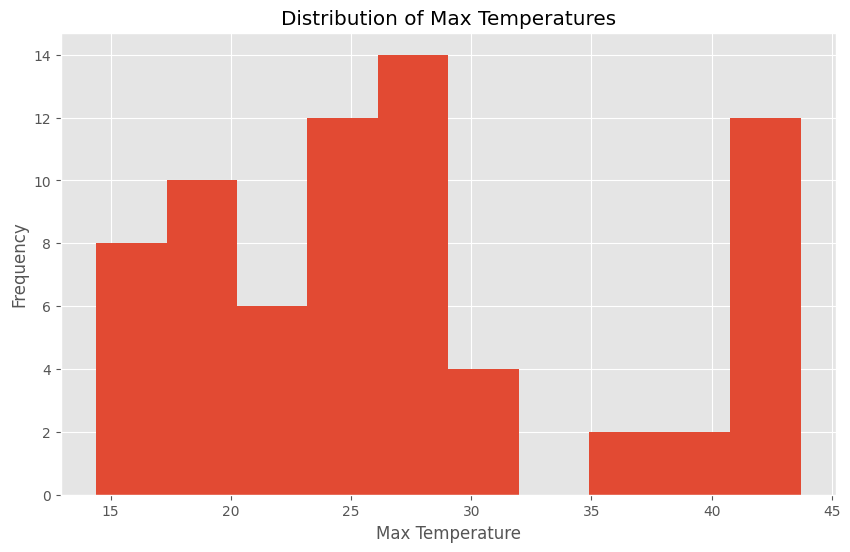

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_5524\771796671.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=cities_list)


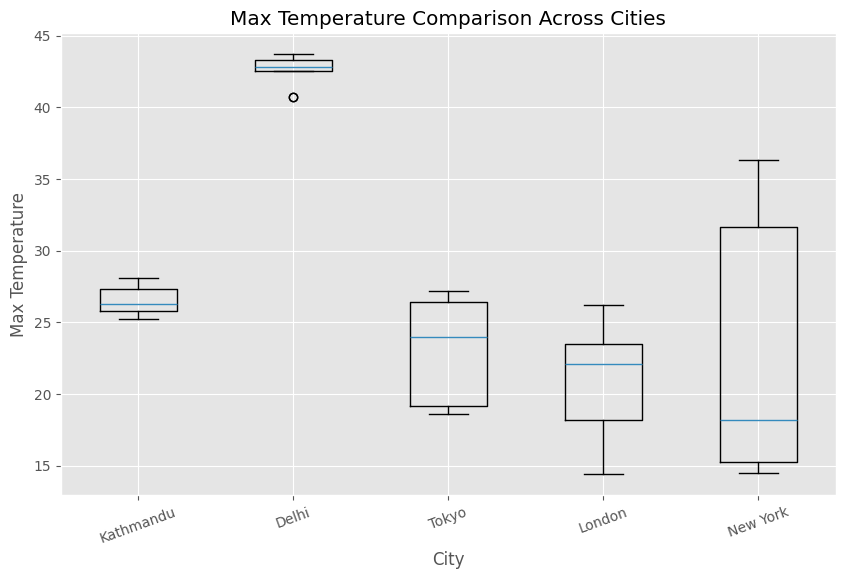

Empty DataFrame
Columns: [id, city, date, max_temp, min_temp]
Index: []


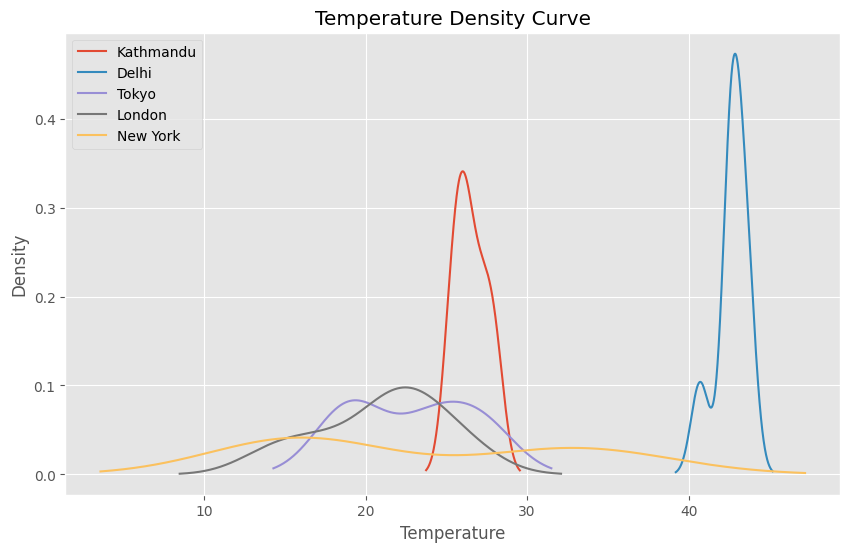

                mean  median       std   min   max
city                                              
Delhi      42.671429    42.8  0.935972  40.7  43.7
Kathmandu  26.528571    26.3  0.987170  25.2  28.1
London     21.000000    22.1  3.823410  14.4  26.2
New York   23.342857    18.2  9.054172  14.5  36.3
Tokyo      22.800000    24.0  3.593156  18.6  27.2
1. Temperature distributions vary across cities.
2. Some cities have larger temperature variation.
3. Boxplots reveal possible outliers.
4. Density curves show spread differences.
5. Average temperatures differ between regions.


In [5]:
import requests
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Nishan@20640904",
    database="weather_db"
)

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS weathers (
    id INT AUTO_INCREMENT PRIMARY KEY,
    city VARCHAR(50),
    date DATE,
    max_temp FLOAT,
    min_temp FLOAT
)
""")

cities = {
    "Kathmandu": (27.7172, 85.3240),
    "Delhi": (28.7041, 77.1025),
    "Tokyo": (35.6762, 139.6503),
    "London": (51.5072, -0.1276),
    "New York": (40.7128, -74.0060)
}

def fetch_weather():

    weather_data = []

    for city, (lat, lon) in cities.items():

        url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=temperature_2m_max,temperature_2m_min&forecast_days=7&timezone=auto"

        try:

            response = requests.get(url, timeout=10)

            data = response.json()

            dates = data["daily"]["time"]

            max_temps = data["daily"]["temperature_2m_max"]

            min_temps = data["daily"]["temperature_2m_min"]

            for date, max_temp, min_temp in zip(dates, max_temps, min_temps):

                weather_data.append((
                    city,
                    date,
                    max_temp,
                    min_temp
                ))

        except requests.exceptions.RequestException as e:

            print(f"Error fetching data for {city}: {e}")

    return weather_data

weather_data = fetch_weather()

insert_query = """
INSERT INTO weathers (city, date, max_temp, min_temp)
VALUES (%s, %s, %s, %s)
"""

cursor.executemany(insert_query, weather_data)

conn.commit()

query = "SELECT * FROM weathers"

df = pd.read_sql(query, conn)
print(df.shape)
print(df.info())
print(df.dtypes)
print(df.isnull().sum())
print((df.isnull().sum() / len(df)) * 100)
print(df.describe())

print(df["city"].value_counts())

plt.figure(figsize=(10,6))
plt.hist(df["max_temp"], bins=10)
plt.title("Distribution of Max Temperatures")
plt.xlabel("Max Temperature")
plt.ylabel("Frequency")
plt.show()

cities_list = df["city"].unique()

boxplot_data = []

for city in cities_list:

    city_temp = df[df["city"] == city]["max_temp"]

    boxplot_data.append(city_temp)

plt.figure(figsize=(10,6))

plt.boxplot(boxplot_data, labels=cities_list)

plt.title("Max Temperature Comparison Across Cities")

plt.xlabel("City")

plt.ylabel("Max Temperature")

plt.xticks(rotation=20)

plt.show()

Q1 = df["max_temp"].quantile(0.25)

Q3 = df["max_temp"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["max_temp"] < lower_bound) |
    (df["max_temp"] > upper_bound)
]

print(outliers)

plt.figure(figsize=(10,6))

for city in cities_list:

    city_data = df[df["city"] == city]["max_temp"]

    city_data.plot(kind="density", label=city)

plt.title("Temperature Density Curve")

plt.xlabel("Temperature")

plt.legend()

plt.show()

summary = df.groupby("city")["max_temp"].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

print(summary)

print("1. Temperature distributions vary across cities.")

print("2. Some cities have larger temperature variation.")

print("3. Boxplots reveal possible outliers.")

print("4. Density curves show spread differences.")

print("5. Average temperatures differ between regions.")

cursor.close()

conn.close()